# This notebook contains examples on DFM and DDFMs on simulated data

In [1]:
import os, sys

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import pandas as pd
import random
from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ as DFM
import tensorflow as tf

from models.ddfm import DDFM
from synthetic_dgp.simulate import SIMULATE

In [2]:
import logging

logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("Logger Level Info")
tf.get_logger().setLevel("ERROR")

INFO:root:Logger Level Info


## Simulation Settings

In [3]:
seed = 123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
# set poly degree, if 1 then linear and the encoder structure is modified to linear single layer
poly_degree = 2
# to store common factor recovery performance
results_dfm = {"smoothed": 0, "filtered": 0}
# for DDFM we can have estimates both from the state space filtering/smoothing and encoder training
results_ddfm = {"smoothed": 0, "filtered": 0, "autoencoder based": 0}
# when the model has a nonlinear decoder, the direct comparison with the above models is via the last neurons which than have a linear mapping to the observables
results_ddfm_nnlin_dec = {
    "smoothed": 0,
    "filtered": 0,
    "autoencoder based": 0,
    "autoencoder based last neurons": 0,
}
results_ddfm_nnlin_dec_joint_var = {k: 0 for k in results_ddfm_nnlin_dec.keys()}
# params sim data
T_obs = 100
r = 3
portion_missings = 0.2
# simulate data
sim = SIMULATE(seed=seed, n=150, r=r, poly_degree=poly_degree)

## Simulate Data and Estimate Models

In [4]:
x = sim.simulate(T_obs, portion_missings=portion_missings)
# dimension is the factor and their nonlinear transformations (when present)
r_f_and_nnlinf = sim.f.shape[1]
if poly_degree == 1:
    # For linear to set the following
    structure_encoder = (r_f_and_nnlinf,)
else:
    structure_encoder = (
        r_f_and_nnlinf * 6,
        r_f_and_nnlinf * 4,
        r_f_and_nnlinf * 2,
        r_f_and_nnlinf,
    )
# for nonlinear decoder
structure_encoder_nnlin = (r_f_and_nnlinf, r * 9, r * 6, r * 3, r)
structure_decoder_nnlin = (r * 3, r * 6, r * 9, r_f_and_nnlinf)

### DFM

In [5]:
%%time
# estimate DFM and set it up consistent with DDFM specs (VAR(1) dynamics on common factors)
dyn_fact_mdl = DFM(
    pd.DataFrame(x),
    factors=1,
    factor_orders=1,
    factor_multiplicities=min(r_f_and_nnlinf, x.shape[1]),
)
res_dyn_fact_mdl = dyn_fact_mdl.fit(disp=1000, maxiter=1000)

EM start iterations, llf=-6631.8
EM converged at iteration 457, llf=-6421.1, convergence criterion=9.9868e-07 < tolerance=1e-06
CPU times: total: 32min 45s
Wall time: 4min 13s


In [6]:
results_dfm["smoothed"] = sim.evaluate(
    res_dyn_fact_mdl.factors["smoothed"].values, f_true=sim.f
)
results_dfm["filtered"] = sim.evaluate(
    res_dyn_fact_mdl.factors["filtered"].values, f_true=sim.f
)
pd.Series(results_dfm)

smoothed    0.758264
filtered    0.758905
dtype: float64

### DDFM with linear decoder

In [7]:
%%time
# estimate ddfm with linear decoder
deep_dyn_fact_mdl = DDFM(
    structure_encoder=structure_encoder,
    factor_order=1,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl.fit(pd.DataFrame(x), build_state_space=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


INFO:DDFM:Convergence achieved in 9 iterations - new loss: 0.18764595420614322 - delta: 0.00014749269952633865 < 0.0005


CPU times: total: 26.1 s
Wall time: 20.5 s


In [8]:
results_ddfm["autoencoder based"] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl.factors_ae, axis=0), f_true=sim.f
)
results_ddfm["filtered"] = sim.evaluate(
    deep_dyn_fact_mdl.factors_filtered, f_true=sim.f
)
results_ddfm["smoothed"] = sim.evaluate(
    deep_dyn_fact_mdl.factors_smoothed, f_true=sim.f
)
pd.Series(results_ddfm)

smoothed             0.961737
filtered             0.951271
autoencoder based    0.967719
dtype: float64

### DDFM with nonlinear decoder

In [9]:
%%time
# estimate ddfm with nonlinear decoder
deep_dyn_fact_mdl_nnlin = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin.fit(pd.DataFrame(x), build_state_space=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


INFO:DDFM:iteration: 10 - new loss: 0.23689618188539396 - delta: 0.0021628500242037198
INFO:DDFM:Convergence achieved in 15 iterations - new loss: 0.23394909644687534 - delta: 0.0001801506012157454 < 0.0005


CPU times: total: 35 s
Wall time: 27.4 s


In [10]:
results_ddfm_nnlin_dec["autoencoder based last neurons"] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.last_neurons, axis=0), f_true=sim.f
)
results_ddfm_nnlin_dec["autoencoder based"] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin.factors_ae, axis=0), f_true=sim.linear_f
)
results_ddfm_nnlin_dec["filtered"] = sim.evaluate(
    deep_dyn_fact_mdl_nnlin.factors_filtered, f_true=sim.linear_f
)
results_ddfm_nnlin_dec["smoothed"] = sim.evaluate(
    deep_dyn_fact_mdl_nnlin.factors_smoothed, f_true=sim.linear_f
)
pd.Series(results_ddfm_nnlin_dec)

smoothed                          0.134773
filtered                          0.133819
autoencoder based                 0.190104
autoencoder based last neurons    0.913763
dtype: float64

### DDFM with nonlinear decoder and VAR dynamics joint-estimation 

In [11]:
%%time
# estimate ddfm with nonlinear decoder and joint var estimation
deep_dyn_fact_mdl_nnlin_jest = DDFM(
    structure_encoder=structure_encoder_nnlin,
    factor_order=1,
    var_loss_weight=5.0,
    structure_decoder=structure_decoder_nnlin,
    use_bias=False,
    link="relu",
    max_iter=1000,
)
deep_dyn_fact_mdl_nnlin_jest.fit(pd.DataFrame(x), build_state_space=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


INFO:DDFM:iteration: 10 - new loss: 0.2556605339050293 - delta: 0.01676109805703163
INFO:DDFM:Convergence achieved in 14 iterations - new loss: 0.24975137412548065 - delta: 0.00034443981712684035 < 0.0005


CPU times: total: 46.8 s
Wall time: 37.7 s


In [12]:
results_ddfm_nnlin_dec_joint_var["autoencoder based last neurons"] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.last_neurons, axis=0), f_true=sim.f
)
results_ddfm_nnlin_dec_joint_var["autoencoder based"] = sim.evaluate(
    np.mean(deep_dyn_fact_mdl_nnlin_jest.factors_ae, axis=0), f_true=sim.linear_f
)
results_ddfm_nnlin_dec_joint_var["filtered"] = sim.evaluate(
    deep_dyn_fact_mdl_nnlin_jest.factors_filtered, f_true=sim.linear_f
)
results_ddfm_nnlin_dec_joint_var["smoothed"] = sim.evaluate(
    deep_dyn_fact_mdl_nnlin_jest.factors_smoothed, f_true=sim.linear_f
)
pd.Series(results_ddfm_nnlin_dec_joint_var)

smoothed                          0.312487
filtered                          0.311143
autoencoder based                 0.334754
autoencoder based last neurons    0.944537
dtype: float64

<Axes: title={'center': 'True Factors'}>

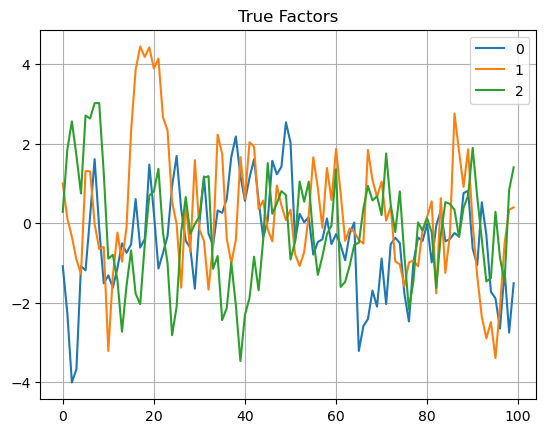

In [13]:
pd.DataFrame(sim.linear_f).plot(grid=True, title="True Factors")

<Axes: title={'center': 'Estimated Factors'}>

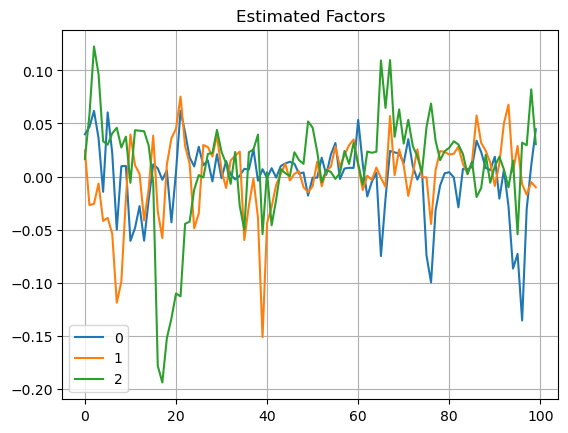

In [14]:
pd.DataFrame(deep_dyn_fact_mdl_nnlin_jest.factors_smoothed).plot(
    grid=True, title="Estimated Factors"
)

## Notes:
- This notebook contains one simulation only to showcase model fitting and factor extraction, for a comparison across models refer to simulations in the "experiments" folder.
- DDFMs can get to very bad solutions due to bad initialization, it is advisable to use different seeds and select the one(s) with lowest loss function.
- "autoencoder based last neurons" are reported for Nonlinear DDFMs for two reasons. First, these are directly comparable to the factors estimated from the other models. Second, nonlinear decoders can generate identification issues that cannot be handled with R2 (and more in general linear) based performance metric.